In [29]:
%load_ext autoreload
%autoreload 2

import os
import json
import cv2
import numpy as np
import torch
import glob

from yolo.yolo import Yolo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device('cuda')
print(device)

cuda


In [31]:
class_dict = {
    'Head': 0,
    'RShoulder': 1,
    'LShoulder': 2,
    'LElbow': 3,
    'LWrist': 4,
    'RHip': 5,
    'LHip': 6,
    'LKnee': 7,
    'RKnee': 8,
    'RAnkle': 9,
    'LAnkle': 10,
    'RElbow': 11,
    'RWrist': 12,
    'Neck': 13
}

In [32]:
def Json_to_yolo_formate(json_data, img_width, img_height):
    yolo_data = []
    for shape in json_data['shapes']:
        x1, y1 = shape['points'][0]
        x2, y2 = shape['points'][1]
        x_left = x1 / img_width
        y_top = y1 / img_height
        width = (x2 - x1) / img_width
        height = (y2 - y1) / img_height
        class_id = class_dict[shape['label']]
        yolo_data.append([class_id, x_left, y_top, width, height])
    return yolo_data

def save_yolo_formate(json_data):
    image_name = json_data['imagePath'].split('.')[0]
    image_path = f"./dataset/{image_name}.png"
    print(image_path)
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    yolo_data = Json_to_yolo_formate(json_data, w, h)
    directory = './dataset/annotation_percentage/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    with open (f'{directory}{image_name}.txt', 'w') as f:
        for data in yolo_data:
            f.write(' '.join(map(str, data)) + '\n')

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2

normal_size = (128,128)

def load_image(path):
    return cv2.imread(path)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def crop_image(image, coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    return image[int(y1):int(y2), int(x1):int(x2)]

def show_image_detail(image, json):
    plt.imshow(image)
    fig, axs = plt.subplots(1, len(json['shapes']), figsize=(15, 15))
    for i, shape in enumerate(json['shapes']):
        croped_test_img = crop_image(image, shape['points'])
        croped_test_img = resize_image(croped_test_img)
        print(croped_test_img.shape)
        axs[i].imshow(croped_test_img)
        axs[i].set_title(shape['label'])
    plt.show()

def resize_image(image, size=normal_size):
    return cv2.resize(image, size)

def vaildate_yolo_formate(path):
    imag = cv2.imread(path)
    yolo_path = os.path.join('dataset', 'annotation', os.path.basename(path).split('.')[0] + '.txt')
    with open(yolo_path, 'r') as boxes:
        for box in boxes:
            box = box.split(' ')
            class_id, x_center, y_center, width, height = map(float, box)
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            cv2.rectangle(imag, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(imag, str(int(class_id)), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    plt.imshow(imag)
    plt.show()

In [34]:
# json_paths = glob.glob('dataset/*.json')
# for json_path in json_paths:
#     json_data = load_json(json_path)
#     save_yolo_formate(json_data)

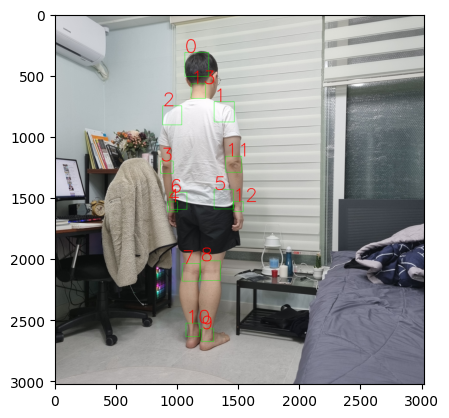

In [35]:
vaildate_yolo_formate('dataset/stand_b_74.png')

In [36]:
def iou(boxes1, boxes2): # box = [x_center, y_center, width, height]
    ious = []
    for box1, box2 in zip(boxes1, boxes2):
        x11, y11, x12, y12 = box1[0] - box1[2]/2, box1[1] - box1[3]/2, box1[0]  + box1[2]/2, box1[1] + box1[3]/2
        x21, y21, x22, y22 = box2[0] - box2[2]/2, box2[1] - box2[3]/2, box2[0]  + box2[2]/2, box2[1] + box2[3]/2

        x_inter1, y_inter1 = max(x11, x21), max(y11, y21)
        x_inter2, t_inter2 = min(x12, x22), min(y12, y22)

        intersection = abs(x_inter2 - x_inter1) * abs(y_inter1 - t_inter2)

        box1_area, box2_area = box1[2] * box1[3], box2[2] * box2[3]
        ious.append(intersection / (box1_area + box2_area - intersection))
    return ious

box1 = [[1, 1, 2, 2], [1, 1, 2, 2]]
box2 = [[2, 1, 2, 2], [3,1,2,2]]
test = iou(box1, box2)
print(test)
    

[0.3333333333333333, 0.0]


In [37]:
box1 = [1,1,2,2]
box2 = [2,1,2,2]
print(iou([box1], [box2]))

[0.3333333333333333]


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
class backDataset(Dataset):
    def __init__(self, transform=None, achor_boxes = None):
        self.img_paths = glob.glob('dataset/*.png')
        self.transform = transform
        self.achor_boxes = achor_boxes * (416/1920)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        original_h, original_w = img.shape[:2]
        boxes = []
        normalize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((416, 416)),
            transforms.ToTensor()
        ])
        with open(os.path.join('dataset', 'annotation', os.path.basename(self.img_paths[idx]).replace('.png', '.txt'))) as f:
            for line in f.readlines():
                new_box = torch.zeros(22)
                class_id, new_box[-3], new_box[-2], new_box[2], new_box[3] = map(float, line.strip().split(' '))
                new_box[-3] = new_box[-3] * 416 / original_w
                new_box[-2] = new_box[-2] * 416 / original_h
                new_box[int(class_id + 5)] = 1
#                 x1 = (center_x - int(w) // 2) * 416 / original_w
#                 y1 = (center_y - int(h) // 2) * 416 / original_h
#                 x2 = (center_x + int(w) // 2) * 416 / original_w
#                 y2 = (center_y + int(h) // 2) * 416 / original_h

                # Find best anchor box
                for abox in self.achor_boxes:
                    pass
    
                # Compute tx, ty, tw, th
        
                # Assign bounding box
                new_box[-1] = 1
                boxes.append(new_box)
        img = normalize(img)
        print(torch.stack(boxes))
        return img, torch.stack(boxes)
    
#         target = [torch.zeros(3, 13, 13, 6), torch.zeros(3, 26, 26, 6), torch.zeros(3, 52, 52, 6)] # Po, x, y, w, h, class
#         for box in boxes:
#             class_id, x1, y1, x2, y2 = box
#             center_x, center_y = (x1 + x2) / 2, (y1 + y2) / 2
#             center_x_percent, center_y_percent = center_x / 416, center_y / 416
#             w, h = x2 - x1, y2 - y1
#             w_percent, h_percent = w / 416, h / 416
#             center_x, center_y, w, h = center_x * 416, center_y * 416, w * 416, h * 416
#             grid_x_13, grid_y_13 = int(center_x // 416 * 13), int(center_y // 416 * 13)
#             grid_x_26, grid_y_26 = int(center_x // 416 * 26), int(center_y // 416 * 26)
#             grid_x_52, grid_y_52 = int(center_x // 416 * 52), int(center_y // 416 * 52)
#             has_anchor = [False, False, False]
#             anchors_ious = [iou([0,0,w,h],[0,0]+self.achor_boxes[i])[0] for i in len(self.achor_boxes)]
#             anchors_index = np.argsort(anchors_ious, axis=0, descending=True)
#             for anchors_ind in anchors_index:
#                 scale = int(anchors_ind // 3)
#                 anchor = int(anchors_ind % 3)
#                 if(scale == 0):
#                     if has_anchor[scale]:
#                         continue
#                     if target[scale][anchor, grid_x_13, grid_y_13, 0] == 0:
#                         target[scale][anchor, grid_x_13, grid_y_13, 0] = 1
#                         target[scale][anchor, grid_x_13, grid_y_13, 1:5] = torch.tensor([center_x, center_y, w, h])
#                         target[scale][anchor, grid_x_13, grid_y_13, 5] = class_id
#                         has_anchor[scale] = True
#                 elif(scale == 1):
#                     if has_anchor[scale]:
#                         continue
#                     if target[scale][anchor, grid_x_26, grid_y_26, 0] == 0:
#                         target[scale][anchor, grid_x_26, grid_y_26, 0] = 1
#                         target[scale][anchor, grid_x_26, grid_y_26, 1:5] = torch.tensor([center_x, center_y, w, h])
#                         target[scale][anchor, grid_x_26, grid_y_26, 5] = class_id
#                         has_anchor[scale] = True
                        
#                 else:
#                     if has_anchor[scale]:
#                         continue
#                     if target[scale][anchor, grid_x_52, grid_y_52, 0] == 0:
#                         target[scale][anchor, grid_x_52, grid_y_52, 0] = 1
#                         target[scale][anchor, grid_x_52, grid_y_52, 1:5] = torch.tensor([center_x, center_y, w, h])
#                         target[scale][anchor, grid_x_52, grid_y_52, 5] = class_id
#                         has_anchor[scale] = True


#         return img, torch.tensor(boxes)
    

In [27]:
test_loader = DataLoader(backDataset(), batch_size=1, shuffle=True)

In [10]:
img, data = test_loader.dataset[0]

tensor([[216.4902,  36.0741, 158.7009, 158.7009,   0.0000,   1.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   1.0000],
        [218.9159,  57.2995, 105.8006, 105.8006,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   1.0000,   1.0000],
        [192.2325,  71.2476, 167.5176, 167.5176,   0.0000,   0.0000,   0.0000,
           1.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   1.0000],
        [248.3283,  73.9766, 189.5594, 189.5594,   0.0000,   0.0000,   1.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   1.0000],
        [299.2693,  86.7119, 127.8424, 127.8424,   0.0000,   0.0000,   0.0000,
         

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


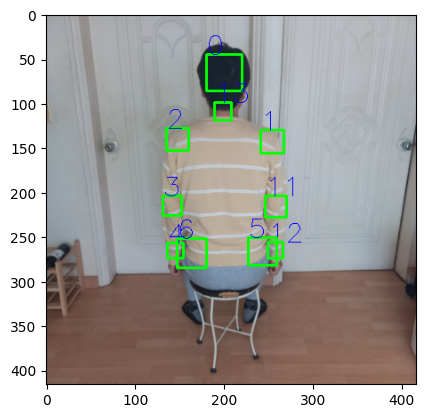

In [11]:
img = img.permute(1, 2, 0)
img = cv2.cvtColor(img.numpy(), cv2.COLOR_BGR2RGB)
# print(data)
for box in data:
    class_id, x1, y1, x2, y2 = box
    cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
plt.imshow(img)


In [12]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

def collate_fn(batch):
    img = [item[0] for item in batch]
    boxes = [item[1] for item in batch]
    max_boxes = max([len(box) for box in boxes])
    print(boxes[0].shape)
    print(max_boxes)
    boxes_list_padded = []
    for box in boxes:
        if box.shape[0] < max_boxes:
            box = torch.cat([box, torch.zeros(max_boxes - box.shape[0], 5)])
        boxes_list_padded.append(box)
    return torch.stack(img), torch.stack(boxes_list_padded)


dataset = backDataset()
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [13]:
test_train_img, test_train_data = next(iter(train_loader))
print(test_train_img.shape)

Invalid SOS parameters for sequential JPEG


torch.Size([14, 5])
14
torch.Size([10, 3, 416, 416])


In [14]:
test_train_img = test_train_img.permute(0, 2, 3, 1)

In [15]:
test_train_data[4][0]

tensor([  0.0000, 177.1308, 106.8467, 204.6440, 134.3599])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


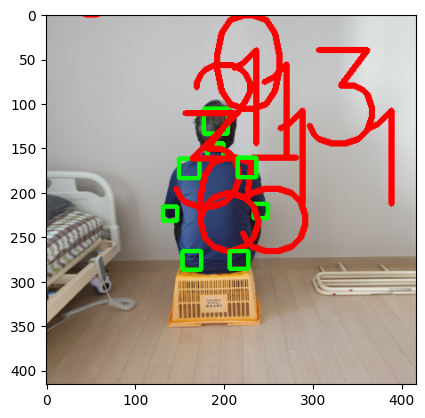

In [16]:
# plt.imshow(test_train_img[0].numpy())
img = cv2.cvtColor(test_train_img[4].numpy(), cv2.COLOR_BGR2RGB)
data = test_train_data[4]
for box in data:
    class_id, x1, y1, x2, y2 = box
    cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 3)
    cv2.putText(img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 5)
plt.imshow(img)

# YOLO
Yolov3 (might be easier)
https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/
https://arxiv.org/abs/1804.02767

In [17]:
anchors = torch.tensor([[151.37092679, 151.37092679], [116.1775567, 116.1775567 ], [ 69.10933737,  69.10933737], 
                        [206.27557981, 206.27557981], [257.97346109, 257.97346109]])

In [91]:
print([0,0].append(anchors[0].tolist()))
print([0,0].extend(anchors[0].tolist()))
print([0,0]+anchors[0].tolist())
print([0][0])

None
None
[0, 0, 151.3709259033203, 151.3709259033203]
0


In [18]:
tt, td = next(iter(train_loader))

torch.Size([10, 5])
14


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


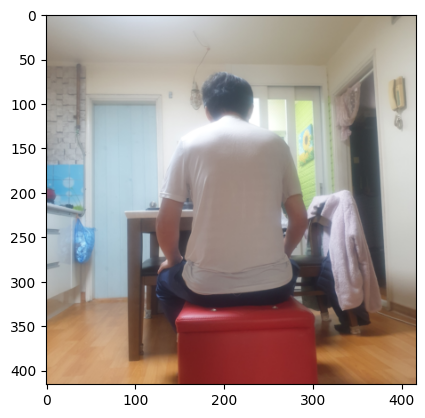

In [19]:
# ttreshape = torch.tensor([[cv2.resize(timg.numpy(), (416, 416), interpolation=cv2.INTER_AREA) for timg in batch] for batch in tt])
timg = cv2.cvtColor(tt.permute(0, 2, 3, 1)[4].to('cpu').numpy(), cv2.COLOR_BGR2RGB)
data = td[4]
for box in data:
    class_id, x1, y1, x2, y2 = box
    cv2.rectangle(timg, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 1)
    cv2.putText(timg, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
plt.imshow(timg)

In [20]:
tt.shape

torch.Size([10, 3, 416, 416])

In [21]:
yolo_test = Yolo(14, anchors.shape[0]).to(device)
tt = tt.to(device)

In [22]:
test_result = yolo_test(tt)

begin yolo
start backbone block 1
post block 1 torch.Size([10, 64, 208, 208])
start block 2
block 2 pre-res
post block 2 torch.Size([10, 128, 104, 104])
start block 3
block 3 pre-res
post block 3 torch.Size([10, 256, 52, 52])
start block 4
block 4 pre-res
post block 4 torch.Size([10, 512, 26, 26])
start block 5
block 5 pre-res
post block 5 torch.Size([10, 1024, 13, 13])
backbone end return
torch.Size([10, 1024, 13, 13])
torch.Size([10, 512, 26, 26])
torch.Size([10, 256, 52, 52])
torch.Size([10, 1024, 13, 13])
l2p torch.Size([10, 512, 13, 13])
torch.Size([10, 512, 26, 26])
torch.Size([10, 512, 26, 26]) torch.Size([10, 512, 26, 26])
l2p torch.Size([10, 256, 26, 26])
torch.Size([10, 256, 52, 52])
torch.Size([10, 256, 52, 52]) torch.Size([10, 256, 52, 52])
l2p torch.Size([10, 128, 52, 52])


In [178]:
test_result = [result.permute(0, 2, 3, 1) for result in test_result] # need to permute to (x, y, 95) b/c 95 is layers, not prediciton list as wanted

In [193]:
test_result[0][0][..., 2:4] = 0
test_result

[tensor([[[[ 1.5436e-01, -3.4088e-02,  0.0000e+00,  ..., -3.4163e-03,
             3.1801e-01,  3.9786e-01],
           [ 1.7216e-01,  1.5449e-01,  0.0000e+00,  ..., -2.0787e-01,
             2.6844e-01,  3.0318e-01],
           [ 4.2694e-01,  9.0697e-02,  0.0000e+00,  ..., -2.6251e-01,
             1.3531e-01,  7.1041e-01],
           ...,
           [-1.7743e-01,  1.3530e-01,  0.0000e+00,  ..., -8.4139e-02,
             1.1892e-01,  3.8578e-02],
           [-9.7951e-02,  6.3989e-02,  0.0000e+00,  ..., -6.9282e-02,
             1.8420e-01,  3.7882e-01],
           [-1.6435e-01,  2.1890e-01,  0.0000e+00,  ..., -7.5776e-02,
             3.8397e-01,  4.0299e-01]],
 
          [[ 4.5092e-01, -3.3739e-01,  0.0000e+00,  ...,  1.6346e-02,
             5.1157e-02, -1.4461e-02],
           [-2.9775e-01, -5.1586e-01,  0.0000e+00,  ..., -1.3542e-01,
             6.7083e-01,  1.6114e-02],
           [ 8.2389e-02, -3.9853e-01,  0.0000e+00,  ..., -1.3366e-01,
             1.8726e-01, -1.5409e-01],


In [171]:
print(td[4])

tensor([[0.0000e+00, 2.0359e+02, 3.4868e+02, 2.3203e+02, 3.7712e+02],
        [4.0625e-01, 6.4350e+00, 9.7851e+00, 7.1741e+00, 1.0524e+01],
        [6.2500e-02, 7.7535e+00, 8.8333e+00, 8.6704e+00, 9.7502e+00],
        [3.1250e-02, 4.6162e+00, 9.0553e+00, 5.4582e+00, 9.8974e+00],
        [9.3750e-02, 7.9578e+00, 6.6750e+00, 8.6876e+00, 7.4048e+00],
        [3.4375e-01, 4.3913e+00, 6.8370e+00, 5.0556e+00, 7.5012e+00],
        [1.2500e-01, 7.8898e+00, 5.5641e+00, 8.4511e+00, 6.1254e+00],
        [3.4375e-01, 4.5948e+00, 5.4254e+00, 5.1935e+00, 6.0242e+00],
        [1.8750e-01, 7.0619e+00, 4.6993e+00, 7.8946e+00, 5.5320e+00],
        [1.5625e-01, 5.1602e+00, 4.6987e+00, 6.0771e+00, 5.6156e+00],
        [2.1875e-01, 6.7026e+00, 2.9372e+00, 7.4418e+00, 3.6763e+00],
        [2.5000e-01, 5.5764e+00, 2.9092e+00, 6.3623e+00, 3.6951e+00],
        [3.1250e-01, 6.8655e+00, 8.2972e-01, 7.4081e+00, 1.3724e+00],
        [2.8125e-01, 5.5923e+00, 7.6550e-01, 6.0788e+00, 1.2520e+00]])


In [169]:
def bounding_loss(anchors, ground_truths, img_scale, scale_down):
    anchors = anchors // scale_down
    
    for i in range(img_scale.shape[0]):
        for j in range(img_scale.shape[1]):
            # Get cell center
            c_x = i + 0.5   # ith cell (top left corner) + 0.5 center offset
            c_y = j + 0.5   # jth cell (top left corner) + 0.5 center offset
            
            # Get prediction offsets
            prediction = img_scale[i][j]
            t_x, t_y, t_w, t_l = prediction[:4]
            
            # Iterate through all anchors
            main_loss = 0    # main loss for the anchor that has the highest IoU with 
            for (p_w, p_l) in anchors:
                b_x = torch.sigmoid(t_x) + c_x
                b_y = torch.sigmoid(t_y) + c_y
                b_w = p_w * torch.exp(t_w)
                b_l = p_l * torch.exp(t_l)
                
                
            '''
            TODO From Paper:
            During training we use sum of squared error loss. If the
            ground truth for some coordinate prediction is tˆ*
            our gradient is the ground truth value (computed from the ground
            truth box) minus our prediction: tˆ* − t*. This ground truth
            value can be easily computed by inverting the equations above.
            '''
            
                

#             print(t_x, t_y, t_w, t_l)
            # Get center of ground truth bbox
#             c_x, c_y, p_w, p_h = gt_bbox[1:] / scale_down
#             cellx_id = c_x // 1
#             celly_id = c_y // 1
#             print('ground truth bb:', c_x, c_y, p_w, p_h)
#             print('grid-cell idx:', cellx_id, celly_id)
            
#             print(img_scales.shape)
#             bb_predict = img_scales[]
            
#         for i in range(cell_predictions.shape[0]):      # x dim
#             for j in range(cell_predictions.shape[1]):  # y dim
#                 cell_boxes = cell_predictions[i][j] # get 95 element tensor with predictions
#                 cell_boxes = torch.split(cell_boxes, (19,) * (cell_boxes.shape[0] // 19)) # Split tensor to num_boxes x 19 (num_classes + 4 + 1) tensors
#                 print(len(cell_boxes), len(cell_boxes[0]))
#                 for bbox in cell_boxes:
#                     t_x, t_y, t_w, t_l, obj = bbox[:5]
#                     class_predicts = bbox[5:]

#     #                         b_x = anchors[0][0]
#                     for anchor in anchors:
#                         b_w = anchor[0] + torch.sigmoid()
#     #                         print(t_x, t_y, t_w, t_l, obj)
#     #                         print(class_predicts.shape)
#                 break
#             break
#         break
#     break
    

def bounding_loss_batch(anchors, ground_truths, predict_boxes):
    '''
    Loss function for bounding boxes. 
    Assumes predict_boxes in shape [b, x, y, c]. 
    Assumes ground_truths to be original resolution. Loss function will down scale.
    '''
    for scale_down, img_scales in zip([32, 16, 8], predict_boxes):   # iterate through each scale
        print()
        print(img_scales.shape)
        for scale in img_scales:
            print(f'Scale: 416x416 -> {416//scale_down}x{416//scale_down} (/{scale_down})')
            loss = bounding_loss(anchors, ground_truths, scale, scale_down)
            return

            
#             bb_predicts, img_x, img_y = scale_predict
#             for i in range(bb_predicts.shape[0])
#             for i in range(scale_predict.shape[-1]):
#                 print(scale_predict[1].shape)
#             print(batch[0].shape)
#             t_x, t_y, t_w, t_l, _ = batch
#             print(t_x, t_y, t_w, t_l)
#         b_x = torch.sigmoid()

In [170]:
bounding_loss_batch(anchors, td[4], test_result)


torch.Size([10, 13, 13, 95])
Scale: 416x416 -> 13x13 (/32)
tensor([[0.0000e+00, 2.0359e+02, 3.4868e+02, 2.3203e+02, 3.7712e+02],
        [4.0625e-01, 6.4350e+00, 9.7851e+00, 7.1741e+00, 1.0524e+01],
        [6.2500e-02, 7.7535e+00, 8.8333e+00, 8.6704e+00, 9.7502e+00],
        [3.1250e-02, 4.6162e+00, 9.0553e+00, 5.4582e+00, 9.8974e+00],
        [9.3750e-02, 7.9578e+00, 6.6750e+00, 8.6876e+00, 7.4048e+00],
        [3.4375e-01, 4.3913e+00, 6.8370e+00, 5.0556e+00, 7.5012e+00],
        [1.2500e-01, 7.8898e+00, 5.5641e+00, 8.4511e+00, 6.1254e+00],
        [3.4375e-01, 4.5948e+00, 5.4254e+00, 5.1935e+00, 6.0242e+00],
        [1.8750e-01, 7.0619e+00, 4.6993e+00, 7.8946e+00, 5.5320e+00],
        [1.5625e-01, 5.1602e+00, 4.6987e+00, 6.0771e+00, 5.6156e+00],
        [2.1875e-01, 6.7026e+00, 2.9372e+00, 7.4418e+00, 3.6763e+00],
        [2.5000e-01, 5.5764e+00, 2.9092e+00, 6.3623e+00, 3.6951e+00],
        [3.1250e-01, 6.8655e+00, 8.2972e-01, 7.4081e+00, 1.3724e+00],
        [2.8125e-01, 5.5923e+0

In [25]:
def train(model, optimizer, epochs=10):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (x, ground_truths) in enumerate(train_loader):
        
            scales = model(x)
        
            # Bounding Box Loss
            loss = bounding_loss(anchors, )

            # Delete inputs/ouputs to free up resources
            del x
            del scales

SyntaxError: expected ':' (1871706568.py, line 4)

In [ ]:
test_result[0].shape

Expected prediction structure `[tx, ty, tw, tl, obj, c1, c2, ..., c14]`

In [ ]:
td[4]

In [ ]:
bounding_loss(ab, td[4], test_result)

In [ ]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

In [ ]:
print(a, b, c)

In [25]:
print(test_result[0].shape)
test_result = [x.permute(0,2,3,1) for x in test_result]

torch.Size([10, 95, 13, 13])


In [37]:
test_result[2].shape

torch.Size([10, 52, 52, 95])

In [36]:
print(td.shape)

torch.Size([10, 14, 5])


In [40]:
def classification_loss(ground_truths, pred):
    # predict_classes: (batch_size, 13, 13, 95)
    # ground_truths: (batch_size, 14, 5) 5: class_id, x_center, y_center, width, height
    pred_boxes = pred.reshape(pred.shape[0], pred.shape[1], pred.shape[2], 5, 19)
    pred_classes = pred_boxes[:, :, :, :, -14:]
    truth_classes = ground_truths[:, :, 0].long()
    print(pred_classes.shape)
    print(truth_classes.shape)
    # loss_fn = torch.nn.CrossEntropyLoss()
    return None
    
    

In [41]:
classification_loss(td, test_result[0])

torch.Size([10, 13, 13, 5, 14])
torch.Size([10, 14])


In [200]:
del test_result
del tt